2026-08-30 21:40:14.453 | INFO     | __main__:reducer_node:52 - reducer shuffle entries: {'Hello': [1], 'world': [1], 'hello': [1, 1], 'atguigu': [1], 'llm': [1]}
2026-08-30 21:40:14.454 | INFO     | __main__:reducer_node:56 - reducer {'Hello': 1, 'world': 1, 'hello': 2, 'atguigu': 1, 'llm': 1}


{'input_values': ['Hello world', 'hello atguigu', 'hello llm'], 'entries': [('Hello', 1), ('world', 1), ('hello', 1), ('atguigu', 1), ('hello', 1), ('llm', 1)], 'word_counts': {'Hello': 1, 'world': 1, 'hello': 2, 'atguigu': 1, 'llm': 1}}


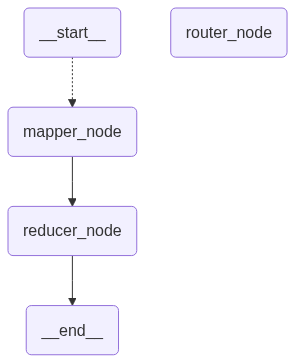

In [8]:
from operator import add
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from loguru import logger
from typing import TypedDict, Annotated, Sequence
from IPython.display import display

from langchain_core.runnables import RunnableConfig
from mdit_py_plugins import wordcount

from main import builder


class OverAllState(TypedDict):
    input_values: list[str]
    entries: Annotated[list[tuple[str,int]],add]
    word_counts: dict[str,int]

class MaperInputState(TypedDict):
    input_value: str

def router_node(state: OverAllState) -> Sequence[Send]:
    input_values = state["input_values"]
    task = []
    for input_value in input_values:
        task.append(
            Send("mapper_node", {"input_value":input_value})
        )
    return task

#接受单独的一句话，切分为单词，组装为元组放到全局状态中
def mapper_node(state: MaperInputState) -> OverAllState:
    input_value = state["input_value"]
    words = input_value.split(" ")
    entries = []
    for word in words:
        entries.append(
            (word, 1)
        )
    return {
        "entries": entries,
    }

def reducer_node(state: OverAllState) -> OverAllState:
    entries = state["entries"]
    shuffle_dict = {}
    for k,v in entries:
        if k not in shuffle_dict:
            shuffle_dict[k] = [v]
        else:
            shuffle_dict[k].append(v)
    logger.info("reducer shuffle entries: {}", shuffle_dict)
    reduce_dict = {}
    for k,v in shuffle_dict.items():
        reduce_dict[k] = sum(v)
    logger.info("reducer {}", reduce_dict)
    return{
        "word_counts": reduce_dict,
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("router_node", router_node)
builder.add_node("mapper_node", mapper_node)
builder.add_node("reducer_node", reducer_node)

builder.add_conditional_edges(START, router_node,path_map={"mapper_node":"mapper_node"})
builder.add_edge("mapper_node", "reducer_node")
builder.add_edge("reducer_node", END)

graph = builder.compile()
res = graph.invoke(
    {
        "input_values":["Hello world", "hello atguigu", "hello llm"]
    }
)
print(res)
display(graph)